# Examples and applications of the EUtils module     

The example here below are extracted from (perl code)

http://www.ncbi.nlm.nih.gov/books/NBK25498/#chapter3
    
and used here below to show how 
- to use BioServices to access to EUtils, the Entrez utilities    
- call Etutils in a proper way (e.g., using EPost)

In [4]:
from bioservices import EUtils
e = EUtils(email="test")

# you should provide your email in one of the 3 following ways:
# e = EUTils(email="yours")
# e = EUtils(); e.email = "yours"
# fill the ./config/bioservices/bioservices.cfg with a section
#     [user]
#     email = yours

## ESearch and ESummary/EFetch example

In [6]:
# Download PubMed records that are indexed in MeSH for both asthma and 
# leukotrienes and were also published in 2009.
query = 'asthma[mesh]+AND+leukotrienes[mesh]+AND+2009[pdat]'
db = 'pubmed'

# here, we use the history that will populate in results the fields called WebEnv and query_key
results = e.ESearch(db, query, usehistory='y')
results

{'count': '56',
 'retmax': '20',
 'retstart': '0',
 'querykey': '1',
 'webenv': 'MCID_69b5d1eb4852756f9c0c8bc4',
 'idlist': ['20113659',
  '20074456',
  '20046412',
  '20021457',
  '20008883',
  '20008181',
  '19912318',
  '19897276',
  '19895589',
  '19894390',
  '19852204',
  '19839969',
  '19811112',
  '19757309',
  '19749079',
  '19739647',
  '19706339',
  '19665766',
  '19648384',
  '19647860'],
 'translationset': [{'from': 'asthma[mesh]', 'to': '"asthma"[MeSH Terms]'},
  {'from': 'leukotrienes[mesh]', 'to': '"leukotrienes"[MeSH Terms]'}],
 'querytranslation': '"asthma"[MeSH Terms] AND "leukotrienes"[MeSH Terms] AND 2009/01/01:2009/12/31[Date - Publication]'}

In [16]:
# we can now resuse the query and webenv values
res = e.ESummary(db,  query_key=results['querykey'], WebEnv=results['webenv'])
len(res)

57

<h2>EPost and ESummary/EFetch example</h2>
- Input: List of Entrez UIDs (integer identifiers, e.g. PMID, GI, Gene ID)
- ESummary Output: XML Document Summaries
- EFetch Output: Formatted data records (e.g. abstracts, FASTA)


 List of Entrez UIDs (integer identifiers, e.g. PMID, GI, Gene ID)

In [23]:
db = 'protein'
id_list = '194680922,50978626,28558982,9507199,6678417'

In [24]:
results = e.EPost(db, id_list)

In [25]:
results

{'WebEnv': 'MCID_69b5d34218d9f5b3b009ae20', 'QueryKey': '1'}

In [26]:
summary = e.ESummary(db, query_key=results['QueryKey'], WebEnv=results['WebEnv'])

In [29]:
summary = e.EFetch(db, id_list, query_key=results['QueryKey'], WebEnv=results['WebEnv'], retmode="text", rettype="fasta")

In [30]:
print(summary[0:500])


b'>XP_603356.4 PREDICTED: similar to Thyroid peroxidase precursor (TPO) [Bos taurus]\nMETAEVQKLPPTNRETRSVPSKKRGCGWVMEGHRQVLESLTPLKTTVLFTRNFMQKSQSQSLNISGPRVV\nRGRWWFGPGLVWSQLEEGLWADGARFPVISAQKRCWQMRARAVLGVVLAVTCAGAVFSFLLRPGGLLWGE\nTEESQVRGIVEASRLLVDKSVYAAMRRNLHKREVISPAQLLSFSKLPEPTSRAASRAAEVMEASVQEAAR\nRGHLRSGPSQLPTDALSEGLLSAIANLSGCLPYMLPPRCPATCLASKYRLISGACNNRDHPRWGASNTAL\nARWLPPAYEDGISEPRGWNPHFLYKGFPLPPVREVTRRIIHASNEAVTGDDRYSDLLTAWGQYIDHDIAF\nTPQSAAPSAPWVGADCQLTCEPRSPCFPIQLPANAAGPACLPFYRSTAACGTGTQGALFGNL'


<h2>Application1: Converting GI numbers to accession numbers </h2>

- Goal: Starting with a list of nucleotide GI numbers, prepare a set of corresponding accession numbers.
- Solution: Use EFetch with &retttype=acc
- Input: $gi_list – comma-delimited list of GI numbers
- Output: List of accession numbers.

In [44]:
gi_list = '24475906,224465210,50978625,9507198';
output = e.EFetch('nucleotide', gi_list, rettype="acc")


In [47]:
print(output.split())

[b'NM_009417.2', b'NM_000547.4', b'NM_001003009.1', b'NM_019353.1']


In [48]:
#  The order of the accessions in the output will be the same order as the GI numbers in $gi_list.

## Application 2: Converting accession numbers to data 
- Goal: Starting with a list of protein accession numbers, return the sequences in FASTA format.
- Solution: Create a string consisting of items separated by 'OR', where each item is an accession number followed by '[accn]'. Example: accn1[accn]+OR+accn2[accn]+OR+accn3[accn]+OR+…
- Submit this string as a &term in ESearch, then use EFetch to retrieve the FASTA data.
- Input: $acc_list – comma-delimited list of accessions
- Output: FASTA data 

In [49]:
acc_list = 'NM_009417,NM_000547,NM_001003009,NM_019353'
query = "+OR+".join(acc_list.split(","))


In [50]:
results = e.ESearch(db='nucleotide', term=query, usehistory='y')

In [52]:
results

{'count': '4',
 'retmax': '4',
 'retstart': '0',
 'querykey': '1',
 'webenv': 'MCID_69b5d7312c03daddd102f918',
 'idlist': ['927442695', '402766536', '1890295337', '350529408'],
 'translationset': [],
 'translationstack': [{'term': 'NM_009417[All Fields]',
   'field': 'All Fields',
   'count': '1',
   'explode': 'N'},
  {'term': 'NM_000547[All Fields]',
   'field': 'All Fields',
   'count': '1',
   'explode': 'N'},
  'OR',
  {'term': 'NM_001003009[All Fields]',
   'field': 'All Fields',
   'count': '1',
   'explode': 'N'},
  'OR',
  {'term': 'NM_019353[All Fields]',
   'field': 'All Fields',
   'count': '1',
   'explode': 'N'},
  'OR'],
 'querytranslation': 'NM_009417[All Fields] OR NM_000547[All Fields] OR NM_001003009[All Fields] OR NM_019353[All Fields]'}

In [55]:
# Note that there is maybe a typo on the NCBI website where protein is used in place of nucleotide. 
# If we set db=protein, we get a bad request response
data = e.EFetch('nucleotide', id='927442695', query_key=results['querykey'], WebEnv=results['webenv'], rettype='fasta', retmode='text')
print(data[0:500])

b'>NM_009417.3 Mus musculus thyroid peroxidase (Tpo), mRNA\nTTCAGAAGTTAAGACCACAGAGAACACACCCAGCGGTGCACATCCTGCTTCTTCCGCTGCTGAGAAAAGG\nAAAACGTTCAGCTCTAGAATGAGAACACTTGGAGCTATGGCAATAATGCTGGTGGTTATGGGAACTGTAA\nTTTTCCTCTCTTTTATCCTGAGAAGCAGAGACATCTTGTGTGGGAAGACCATGAAGTCCCATGTTATCAG\nTGCTGTGGAAACGAGCCAGCTCATGGTGGACCATGCAGTCTACAACACCATGAAAAGAAACCTCAAGAAA\nAGGGAAGTCCTTTCTCCAGCCCAGCTTCTCTCTTTCTTTAAGCTGCCCGAGTCCACCAGTGGGGCTATTT\nCCCGAGCAGCAGAGATTATGGAAACATCAATACAAGTCATGAAACGTGAACAGTCACAGTTCTCCACGGA\nTGCCTTATCAGCAGACA'


<h2>Application 3: Retrieving large datasets </h2>
- Goal: Download all chimpanzee mRNA sequences in FASTA format (>50,000 sequences).
- Solution: First use ESearch to retrieve the GI numbers for these sequences and post them on the History server, then use multiple EFetch calls to retrieve the data in batches of 500.
- Input: query – chimpanzee[orgn]+AND+biomol+mrna[prop]
- Output: A file named "chimp.fna" containing FASTA data.

In [57]:
query = 'chimpanzee[orgn]+AND+biomol+mrna[prop]'

In [58]:
output = e.ESearch(db='nucleotide', term=query, usehistory='y')

In [61]:
# there are lots of entries and we get only 20 by default
output['count']

'249172'

In [66]:
output

{'count': 1501,
 'retmax': '20',
 'retstart': '0',
 'querykey': '1',
 'webenv': 'MCID_69b5d823181ddf200d0f6376',
 'idlist': ['525345357',
  '2715064810',
  '2501356691',
  '525345305',
  '525344293',
  '525343382',
  '525342631',
  '350539458',
  '350534731',
  '347658977',
  '2715065062',
  '2715065044',
  '302699203',
  '347658950',
  '334724474',
  '525343649',
  '160333302',
  '57113938',
  '2715065097',
  '302699216'],
 'translationset': [{'from': 'chimpanzee[orgn]',
   'to': '"Pan troglodytes"[Organism]'}],
 'translationstack': [{'term': '"Pan troglodytes"[Organism]',
   'field': 'Organism',
   'count': '1',
   'explode': 'Y'},
  {'term': 'biomol mrna[prop]', 'field': 'prop', 'count': '1', 'explode': 'N'},
  'AND'],
 'querytranslation': '"Pan troglodytes"[Organism] AND biomol mrna[prop]'}

In [70]:
# very slow and large file. For demonstration, let us get only 4 batches of 500 sequences
retmax = 500
output['count']=1501
with open('chimp.rna', 'w') as fh:
    # retrieve data in batch of 500
    for i in range(0, int(output['count']/retmax) + 1):
        data = e.EFetch('nucleotide', WebEnv=output['webenv'], retstart=i*retmax, query_key=output['querykey'], 
                 retmax=retmax, retmode='text', rettype='fasta')
        fh.write(data)
        print("{0} batches out of {1} done".format(i+1, int(output.Count)/retmax+1))

# delete the file
#import os
#os.remove('chimp.rna')

TypeError: EUtils.EFetch() missing 1 required positional argument: 'id'

<h2>Application 4: Finding unique sets of linked records for each member of a large dataset</h2>
- Goal: Download separately the SNP rs numbers (identifiers) for each current gene on human chromosome 20.
- Solution: First use ESearch to retrieve the Gene IDs for the genes, and then assemble an ELink URL where each Gene ID is submitted as a separate &id parameter.
- Input: query – human[orgn]+AND+20[chr]+AND+alive[prop]
- Output: A file named "snp_table" containing on each line the gene id followed by a colon (":") followed by a comma-delimited list of the linked SNP rs numbers.

In [71]:
query = 'human[orgn]+AND+20[chr]+AND+alive[prop]'
db1 = 'gene'
db2 = 'snp'
linkname = 'gene_snp'

Notes: The retmax parameter in the ESearch call is set to 5000, as this is a reasonable limit to the number of IDs to send to ELink in one request (if you send 5000 IDs, you are effectively performing 5000 ELink operations). If you need to link more than 5000 records, add &retstart to the ESearch call and repeat the entire procedure for each batch of 5000 IDs, incrementing &retstart for each batch like in application 3.


In [72]:
output = e.ESearch(db=db1, term=query, usehistory='y', RetMax=5000)

WARNING [bioservices.EUtils:193]:  RetMax does not seem to be a known parameter. Use it anyway but may be ignored


In [85]:
ids = output['idlist'][0:10]  # only 10 ids to speed up the example
ids

['4318', '6714', '5621', '1471', '1869', '6790', '650', '2778', '5111', '598']

Here, we retrieve 200 identifiers using the ELink method, which is based on WSDL. 
THe number of identifiers is limited to 200 with this service

In [86]:
results = e.ELink(db1, dbfrom=db2, linkname=linkname, id=ids)

On NCBI page, they use the REST service instead. You can manually call the service as follows so thast you can use HTTP POST request. With REST and a HTTP post request, you can get 5000 identifiers.

In [88]:
from bioservices import REST
elink = REST("elink", url = 'http://eutils.ncbi.nlm.nih.gov/entrez/eutils/')

INFO    [bioservices.elink:354]:  Initialising elink service (REST)


In [89]:
ids = output.IdList.Id[0:00]

res = elink.http_post("elink.fcgi", frmt='xml', 
                params={'dbfrom':db1, 'db':db2, 'id':ids, 'linkname':linkname, 'retmode':'text'}, 
                headers={'Content-Type': 'application/x-www-form-urlencoded', 'User-Agent':'elink'} )

AttributeError: 'dict' object has no attribute 'IdList'

In [ ]:
res = elink.easyXML(res)

In [ ]:
identifiers = {}

for link in res.root.getchildren():
    this_id = link.getchildren()[1].getchildren()[0].text
    links = [this.find('Id').text for this in link.find('LinkSetDb').findall('Link')]
    identifiers[this_id] = links[:]


In [ ]:
identifiers.keys()[0:10]



In [124]:
len(identifiers['4318'])

487

In [126]:
# plot the histogram of the number of links for each identifier


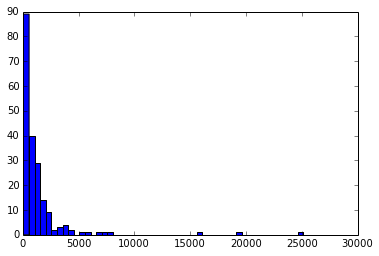

In [129]:
_ = hist([len(identifiers[k]) for k in identifiers.keys()], 50)